
# Lithospheric flexure from a real topographic profile

This notebook applies the 1-D elastic plate flexure equation to a real mountain-range cross section.

We will:

1. Fetch a topographic profile between two latitude/longitude coordinates.
2. Compute the surface load.
3. Fourier-transform the load.
4. Comput the elastic-plate response in wavenumber space using the equation from the slides.
5. Inverse-transform the result to obtain lithospheric deflection.

For a plate of constant flexural rigidity $D$,

$$
D\frac{d^4 w}{dx^4} + \Delta\rho g\,w = q(x),
$$

where

$$
D = \frac{E h^3}{12(1-\nu^2)}.
$$

After a Fourier transform,

$$
\hat w(k) =
\frac{\hat q(k)}
{Dk^4+\Delta\rho g}.
$$

The important idea is that an arbitrary load is just a sum of sinusoidal Fourier components. Each wavelength is flexed by a different amount.

**Sign convention used here:** $w>0$ means downward deflection.

### Elevation data

The profile is queried from the free [OpenTopoData](https://www.opentopodata.org/) public API using its global ETOPO1 dataset. This is deliberately low resolution because we are interested in mountain-range-scale wavelengths, not individual peaks.

The public service is rate-limited, so avoid repeatedly re-running the download cell unnecessarily.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import requests

plt.rcParams["figure.figsize"] = (10, 4)

def pad_for_fft(values, factor=4):
    """
    Center a 1-D signal in a larger zero-padded array.

    Padding reduces interaction with periodic copies implied by the FFT.
    Returns the padded array and the slice that recovers the original data.
    """
    n = len(values)
    padded = np.zeros(factor * n, dtype=float)

    start = (len(padded) - n) // 2
    original_slice = slice(start, start + n)
    padded[original_slice] = values

    return padded, original_slice



## 1. Fetch a topographic cross section

Enter the two endpoints as `(latitude, longitude)`.

The function asks OpenTopoData for equally spaced samples along the line and then calculates cumulative distance using the haversine formula.

The default example crosses the central Andes near $20^\circ$S.


In [ ]:

import numpy as np
import requests
import xarray as xr
from io import BytesIO


def fetch_topographic_profile(point1, point2, spacing_km=3.0):
    """
    Fetch an ETOPO 2022 topographic profile between two coordinates.

    Parameters
    ----------
    point1, point2 : tuple
        (latitude, longitude) in degrees.
    spacing_km : float
        Approximate spacing of profile samples in km.

    Returns
    -------
    distance_km : ndarray
        Distance along profile [km].
    elevation_m : ndarray
        Interpolated surface elevation [m].
    lat : ndarray
        Latitude of profile points.
    lon : ndarray
        Longitude of profile points.
    """

    lat1, lon1 = point1
    lat2, lon2 = point2

    # --------------------------------------------------
    # Great-circle distance
    # --------------------------------------------------
    R = 6371.0  # km

    phi1, phi2 = np.radians([lat1, lat2])
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = (
        np.sin(dphi / 2)**2
        + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    )

    total_distance = 2 * R * np.arcsin(np.sqrt(a))

    n = max(2, int(np.ceil(total_distance / spacing_km)) + 1)

    # --------------------------------------------------
    # Profile coordinates
    # For mountain-range-scale profiles this simple
    # interpolation is generally sufficient.
    # --------------------------------------------------
    lat = np.linspace(lat1, lat2, n)
    lon = np.linspace(lon1, lon2, n)

    # ETOPO ERDDAP uses longitude 0 ... 360
    lon360 = lon % 360

    # --------------------------------------------------
    # Bounding box with small buffer
    # --------------------------------------------------
    buffer_deg = 0.05

    lat_min = max(-89.9979, lat.min() - buffer_deg)
    lat_max = min(89.9979, lat.max() + buffer_deg)

    lon_min = lon360.min() - buffer_deg
    lon_max = lon360.max() + buffer_deg

    # --------------------------------------------------
    # Download only the required ETOPO subset
    # --------------------------------------------------
    base = (
        "https://oceanwatch.pifsc.noaa.gov/erddap/griddap/"
        "ETOPO_2022_v1_15s.nc"
    )

    query = (
        f"?z"
        f"[({lat_min}):({lat_max})]"
        f"[({lon_min}):({lon_max})]"
    )

    response = requests.get(base + query, timeout=60)
    response.raise_for_status()

    ds = xr.open_dataset(BytesIO(response.content))

    # --------------------------------------------------
    # Interpolate DEM onto profile
    # --------------------------------------------------
    elevation = ds["z"].interp(
        latitude=xr.DataArray(lat, dims="points"),
        longitude=xr.DataArray(lon360, dims="points"),
    ).values

    # --------------------------------------------------
    # Distance along profile
    # --------------------------------------------------
    lat_r = np.radians(lat)
    lon_r = np.radians(lon)

    dlat = np.diff(lat_r)
    dlon = np.diff(lon_r)

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat_r[:-1])
        * np.cos(lat_r[1:])
        * np.sin(dlon / 2)**2
    )

    segment_km = 2 * R * np.arcsin(np.sqrt(a))
    distance_km = np.r_[0, np.cumsum(segment_km)]

    return distance_km, elevation, lat, lon

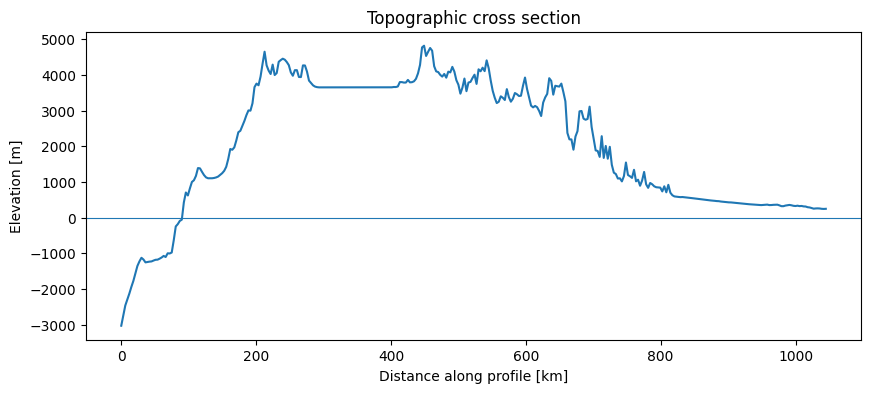

In [ ]:

# --- Choose your cross section here ---

point1 = (-20.0, -71.0)   # (latitude, longitude)
point2 = (-20.0, -61.0)

x_km, elevation_m, lat, lon = fetch_topographic_profile(
    point1, point2, spacing_km=3
)

plt.plot(x_km, elevation_m)
plt.axhline(0, linewidth=0.8)
plt.xlabel("Distance along profile [km]")
plt.ylabel("Elevation [m]")
plt.title("Topographic cross section")
plt.show()


In [ ]:

# Physical parameters
g = 9.81                 # m s^-2
rho_load = 2700.0        # kg m^-3, density of topographic load
rho_m = 3300.0           # kg m^-3
rho_c = 2800.0           # kg m^-3
delta_rho = rho_m - rho_c

E = 70e9                 # Pa
nu = 0.25
h = 40e3                # elastic thickness [m]

D = E * h**3 / (12 * (1 - nu**2))

print(f"Profile length: {x_km[-1]:.0f} km")
print(f"Elastic thickness h: {h/1000:.0f} km")
print(f"Flexural rigidity D: {D:.3e} N m")


Profile length: 1045 km
Elastic thickness Te: 10 km
Flexural rigidity D: 2.667e+21 N m



## 2. Convert topography into a load

**Appoximate the crustal load!** The load variable should be named $q$

In [ ]:


q=


## 3. Fourier transform the load

For a discretely sampled profile we use the real Fourier transform:

$$
q(x) \longrightarrow \hat{q}(k)
$$

The spatial wavenumber is

$$
k = \frac{2\pi}{\lambda}.
$$

Before the transform, the helper function defined at the top adds zero padding
to reduce artificial interaction between periodic copies of the profile.


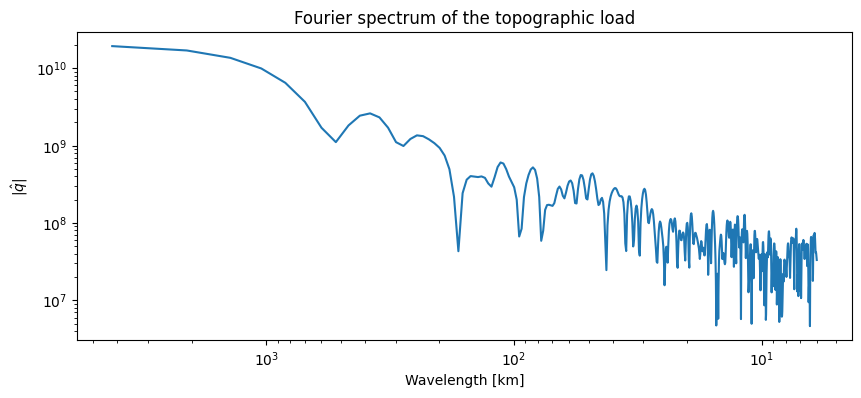

In [ ]:
# Spatial spacing [m]
dx = (x_km[1] - x_km[0]) * 1000.0

# Prepare the load for the FFT
q_pad, profile_slice = pad_for_fft(q)

# Fourier transform
q_hat = np.fft.rfft(q_pad)
k = 2 * np.pi * np.fft.rfftfreq(len(q_pad), d=dx)

# Convert wavenumber to wavelength for plotting
wavelength_km = np.full_like(k, np.nan, dtype=float)
wavelength_km[1:] = (2 * np.pi / k[1:]) / 1000.0

plt.loglog(wavelength_km[1:], np.abs(q_hat[1:]))
plt.gca().invert_xaxis()
plt.xlabel("Wavelength [km]")
plt.ylabel(r"$|\hat{q}|$")
plt.title("Fourier spectrum of the topographic load")
plt.show()


## 4. Apply the flexural response in Fourier space

Determine the Transfer Function $H(k)$ so the following relationship is true:
$$
\hat w(k)
=
H(k)\hat q(k).
$$

Plot $H$ as a function of wavelength!
And determine $\hat w(k)$.


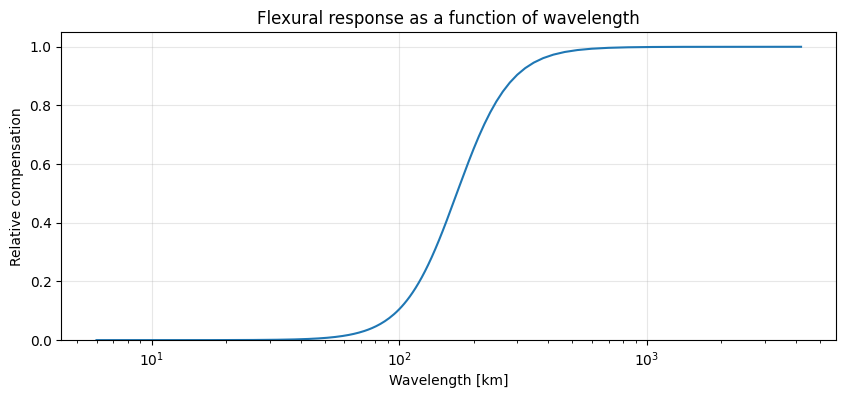

In [ ]:

# Flexural transfer function
H =
# Deflection in Fourier space
w_hat =



## 5. Inverse Fourier transform

Now transform $\hat w(k)$ back into physical space:

$$
\hat w(k) \longrightarrow w(x).
$$

The result is the downward deflection predicted by the elastic-plate model.


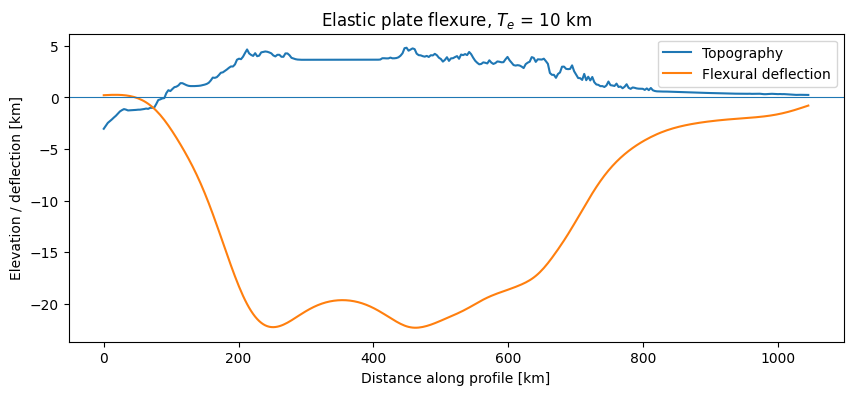

In [ ]:
# Inverse Fourier transform
w_pad = np.fft.irfft(w_hat, n=len(q_pad))

# Keep only the part corresponding to our topographic profile
w_m = w_pad[profile_slice]

fig, ax = plt.subplots()

ax.plot(x_km, elevation_m / 1000, label="Topography")
ax.plot(x_km, -w_m / 1000, label="Flexural deflection")
ax.axhline(0, linewidth=0.8)

ax.set_xlabel("Distance along profile [km]")
ax.set_ylabel("Elevation / deflection [km]")
ax.set_title(f"Elastic plate flexure, $T_e$ = {h/1000:.0f} km")
ax.legend()
plt.show()


## Optional: compare several elastic thicknesses

This is useful after you understand the single-$T_e$ calculation above.


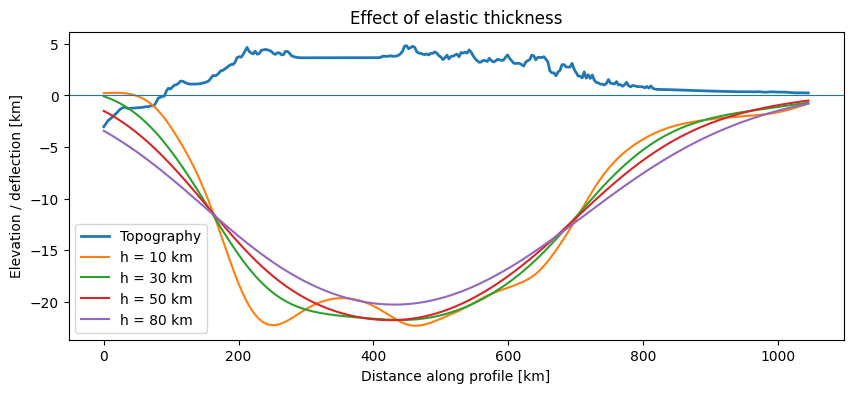

In [ ]:
#@title compare several elastic thicknesses
h_values_km = [10, 30, 50, 80]

plt.plot(x_km, h / 1000, linewidth=2, label="Topography")

for h_km in h_values_km:
    h_i = h_km * 1000.0
    D_i = E * h_i**3 / (12 * (1 - nu**2))
    H_i = 1.0 / (D_i * k**4 + delta_rho * g)

    w_i_pad = np.fft.irfft(q_hat * H_i, n=len(q_pad))
    w_i = w_i_pad[profile_slice]

    plt.plot(x_km, -w_i / 1000, label=f"h = {h_km} km")

plt.axhline(0, linewidth=0.8)
plt.xlabel("Distance along profile [km]")
plt.ylabel("Elevation / deflection [km]")
plt.title("Effect of elastic thickness")
plt.legend()
plt.show()


---

### Notes on interpretation

This notebook is intended to demonstrate the **spectral mechanics of plate flexure**, not to reproduce the full tectonic structure of a mountain belt.

The main assumptions are:

- thin elastic plate,
- constant and isotropic $D$,
- small deflections/slopes,
- constant density contrast,
- topography treated as an applied surface load,
- 1-D geometry,
- no horizontal plate force $P$,
- no time dependence or viscoelastic relaxation.

The FFT still implies periodic boundary conditions; the helper function uses padding only to reduce edge interaction.
